In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
norbertelter_pcb_defect_dataset_path = kagglehub.dataset_download('norbertelter/pcb-defect-dataset')

print('Data source import complete.')


100%|██████████| 1.10G/1.10G [01:02<00:00, 18.9MB/s]

Extracting files...


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
os.listdir("/kaggle/input")


[]

In [6]:
print(norbertelter_pcb_defect_dataset_path)


/root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2


In [7]:
dataset_path = norbertelter_pcb_defect_dataset_path
os.listdir(dataset_path)


['pcb-defect-dataset']

In [5]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.6 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
dataset_path = norbertelter_pcb_defect_dataset_path + "/pcb-defect-dataset"
print(dataset_path)


/root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset


In [13]:
import os
os.listdir(dataset_path)


['test', 'data.yaml', 'train', 'val']

In [14]:
os.listdir(os.path.join(dataset_path, "train"))


['images', 'labels']

In [15]:
os.listdir(os.path.join(dataset_path, "val"))


['images', 'labels']

In [16]:
with open(os.path.join(dataset_path, "data.yaml")) as f:
    print(f.read())


path: ../pcb-defect-dataset
train: train
val: val
test: test

names:
  0: mouse_bite
  1: spur
  2: missing_hole
  3: short
  4: open_circuit
  5: spurious_copper



In [17]:
%%writefile data.yaml
path: /root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset

train: train
val: val
test: test

names:
  0: missing_hole
  1: short
  2: open_circuit


Writing data.yaml


In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    workers=2
)


Ultralytics 8.3.250 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fffd11eea0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [22]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")


In [23]:
import os
os.listdir("/content/runs/detect/predict")


['rotation_90_light_04_open_circuit_04_1_600.jpg',
 'rotation_270_light_04_missing_hole_05_3_600.jpg',
 'l_light_10_spur_02_1_600.jpg',
 'rotation_270_light_12_missing_hole_03_3_600.jpg',
 'rotation_90_light_06_open_circuit_09_2_600.jpg',
 'light_11_missing_hole_08_3_600.jpg',
 'light_05_spur_09_1_600.jpg',
 'light_12_short_09_4_600.jpg',
 'light_06_spur_03_5_600.jpg',
 'l_light_08_missing_hole_08_3_600.jpg',
 'rotation_270_light_07_short_08_3_600.jpg',
 'rotation_270_light_06_short_02_2_600.jpg',
 'rotation_270_light_08_spur_02_1_600.jpg',
 'rotation_90_light_05_spur_10_1_600.jpg',
 'rotation_90_light_10_open_circuit_05_2_600.jpg',
 'rotation_90_light_09_spur_06_2_600.jpg',
 'l_light_12_missing_hole_08_1_600.jpg',
 'rotation_270_light_07_open_circuit_08_3_600.jpg',
 'rotation_90_light_01_missing_hole_08_2_600.jpg',
 'l_light_06_spur_04_1_600.jpg',
 'light_01_mouse_bite_17_2_600.jpg',
 'l_light_04_mouse_bite_18_5_600.jpg',
 'l_light_08_short_06_2_600.jpg',
 'rotation_270_light_05_short

In [29]:
results = model.predict(
    source=dataset_path + "/test/images",
    conf=0.4,
    save=True
)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1068 /root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/images/l_light_01_missing_hole_04_2_600.jpg: 640x640 2 open_circuits, 8.2ms
image 2/1068 /root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/images/l_light_01_missing_hole_07_2_600.jpg: 640x640 2 open_circuits, 7.3ms
image 3/1068 /root/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versi

In [30]:
import os
os.listdir("/content/runs/detect/predict")


['rotation_90_light_04_open_circuit_04_1_600.jpg',
 'rotation_270_light_04_missing_hole_05_3_600.jpg',
 'l_light_10_spur_02_1_600.jpg',
 'rotation_270_light_12_missing_hole_03_3_600.jpg',
 'rotation_90_light_06_open_circuit_09_2_600.jpg',
 'light_11_missing_hole_08_3_600.jpg',
 'light_05_spur_09_1_600.jpg',
 'light_12_short_09_4_600.jpg',
 'light_06_spur_03_5_600.jpg',
 'l_light_08_missing_hole_08_3_600.jpg',
 'rotation_270_light_07_short_08_3_600.jpg',
 'rotation_270_light_06_short_02_2_600.jpg',
 'rotation_270_light_08_spur_02_1_600.jpg',
 'rotation_90_light_05_spur_10_1_600.jpg',
 'rotation_90_light_10_open_circuit_05_2_600.jpg',
 'rotation_90_light_09_spur_06_2_600.jpg',
 'l_light_12_missing_hole_08_1_600.jpg',
 'rotation_270_light_07_open_circuit_08_3_600.jpg',
 'rotation_90_light_01_missing_hole_08_2_600.jpg',
 'l_light_06_spur_04_1_600.jpg',
 'light_01_mouse_bite_17_2_600.jpg',
 'l_light_04_mouse_bite_18_5_600.jpg',
 'l_light_08_short_06_2_600.jpg',
 'rotation_270_light_05_short

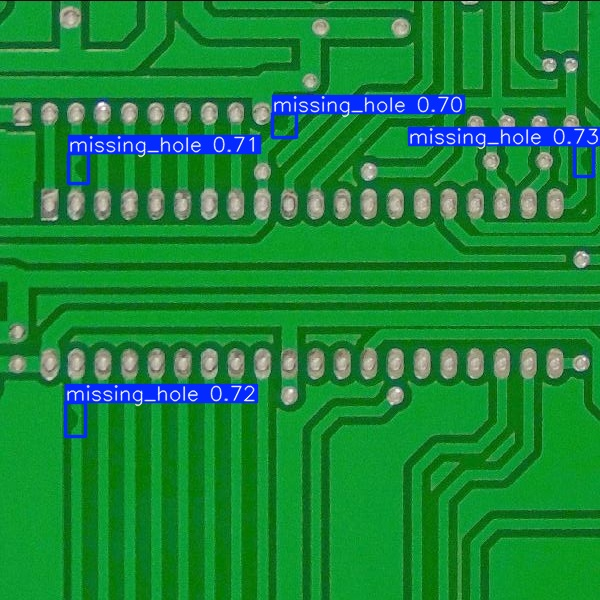

In [34]:
from IPython.display import Image, display
display(Image("/content/runs/detect/predict/rotation_90_light_05_mouse_bite_09_4_600.jpg"))


In [32]:
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0]
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        area = (x2 - x1) * (y2 - y1)
        severity = "High" if area > 5000 else "Low"

        print(f"Defect:{cls} | Conf:{conf:.2f} | Center:({cx},{cy}) | Severity:{severity}")


Defect:2 | Conf:0.77 | Center:(157,253) | Severity:Low
Defect:2 | Conf:0.74 | Center:(228,95) | Severity:Low
Defect:2 | Conf:0.78 | Center:(456,32) | Severity:Low
Defect:2 | Conf:0.78 | Center:(245,482) | Severity:Low
Defect:2 | Conf:0.73 | Center:(321,327) | Severity:Low
Defect:2 | Conf:0.75 | Center:(228,95) | Severity:Low
Defect:2 | Conf:0.71 | Center:(561,13) | Severity:Low
Defect:2 | Conf:0.78 | Center:(153,25) | Severity:Low
Defect:2 | Conf:0.74 | Center:(86,588) | Severity:Low
Defect:2 | Conf:0.75 | Center:(96,574) | Severity:Low
Defect:2 | Conf:0.74 | Center:(453,539) | Severity:Low
Defect:0 | Conf:0.70 | Center:(319,545) | Severity:Low
Defect:0 | Conf:0.66 | Center:(53,341) | Severity:Low
Defect:0 | Conf:0.72 | Center:(431,434) | Severity:Low
Defect:0 | Conf:0.71 | Center:(291,185) | Severity:Low
Defect:0 | Conf:0.72 | Center:(284,74) | Severity:Low
Defect:1 | Conf:0.69 | Center:(465,378) | Severity:Low
Defect:1 | Conf:0.64 | Center:(530,453) | Severity:Low
Defect:1 | Conf:0.7

In [33]:
class_names = {
    0: "missing_hole",
    1: "short",
    2: "open_circuit"
}

for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])
        cls_name = class_names[cls_id]
        conf = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0]
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        area = (x2 - x1) * (y2 - y1)
        severity = "High" if area > 8000 else "Low"

        print(
            f"Defect: {cls_name} | "
            f"Confidence: {conf:.2f} | "
            f"Center: ({cx}, {cy}) | "
            f"Severity: {severity}"
        )


Defect: open_circuit | Confidence: 0.77 | Center: (157, 253) | Severity: Low
Defect: open_circuit | Confidence: 0.74 | Center: (228, 95) | Severity: Low
Defect: open_circuit | Confidence: 0.78 | Center: (456, 32) | Severity: Low
Defect: open_circuit | Confidence: 0.78 | Center: (245, 482) | Severity: Low
Defect: open_circuit | Confidence: 0.73 | Center: (321, 327) | Severity: Low
Defect: open_circuit | Confidence: 0.75 | Center: (228, 95) | Severity: Low
Defect: open_circuit | Confidence: 0.71 | Center: (561, 13) | Severity: Low
Defect: open_circuit | Confidence: 0.78 | Center: (153, 25) | Severity: Low
Defect: open_circuit | Confidence: 0.74 | Center: (86, 588) | Severity: Low
Defect: open_circuit | Confidence: 0.75 | Center: (96, 574) | Severity: Low
Defect: open_circuit | Confidence: 0.74 | Center: (453, 539) | Severity: Low
Defect: missing_hole | Confidence: 0.70 | Center: (319, 545) | Severity: Low
Defect: missing_hole | Confidence: 0.66 | Center: (53, 341) | Severity: Low
Defect: